# AlphaFold vs. Experimental (PDB) Structures: Geometry, ESP, and Model Generalization

Answers `data/datasets/DATA_ORIGINS.md`'s **RQ2**: *do differences between
AF-predicted and experimentally-determined structures produce localized ESP
differences that the model fails to predict?* -- and the sharper question
behind it: **do the models do significantly worse on real experimental
structures than on the AlphaFold structures they were trained on?** If so,
that's evidence of overfitting to AF-specific geometric quirks; if not,
that's evidence the models generalize to real structures.

**Dataset**: 41 proteins with both an AF structure (pLDDT >= 80) and a
matched PDB crystal structure (resolution <= 2.0 A, R-factor <= 0.25, >= 95%
sequence coverage, X-ray only), length-stratified 0-1000 aa. Both sides
already fully processed through the identical PDB2PQR/APBS/MSMS/ESP-sampling
pipeline (`~/thesis/pdb_comparison_data/{af,pdb}/`) -- **never used for
training**. One pair (Q01532) is missing its PDB-side ESP file in the source
data and is excluded, leaving **40 pairs**.

**A real methodological correction made while building this notebook's data**:
naive positional or resid-based CA pairing between the two structures is
*wrong* -- PDB crystal structures commonly have unresolved N-/C-terminal
residues (e.g. a cleaved initiator Met) that shift their internal residue
numbering relative to the AF/UniProt sequence, with an offset that varies
per structure. The fix (`scripts/compute_pdb_af_agreement.py`) is a proper
global sequence alignment (Biopython `PairwiseAligner`) before Kabsch --
validated by recomputing CA-RMSD and matching the dataset's own
pre-existing `ca_rmsd_vs_af` values to within 0.005 A on average across all
40 pairs.

**Pipeline**:
1. `scripts/eval_pdb_comparison.py` -- graph build + frozen-backbone
   inference with both champions, run separately on the AF-side and
   PDB-side structures, written to a directory separate from the real
   848-protein test-split predictions.
2. `scripts/compute_pdb_af_agreement.py` -- sequence-aligned Kabsch CA-RMSD
   + cross-structure RBF-interpolated ESP-field Pearson r/RMSE per pair
   (same technique as `compute_seed_agreement.py`'s inter-seed comparison).

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, wilcoxon

sys.path.insert(0, str(Path("..").resolve()))

MODEL_COLORS = {"attention": "steelblue", "distance": "darkorange"}

---
## 1. Load Cached Outputs

In [2]:
agreement = pd.read_csv("/home/student/thesis/outputs/pdb_af_comparison.csv")
eval_summary = pd.read_csv("/home/student/thesis/outputs/pdb_comparison_eval_summary.csv")

print(f"{len(agreement)} AF<->PDB pairs with full geometry + ESP-field comparison")
print(f"Mean alignment coverage: {agreement['alignment_coverage'].mean():.1%}")

# Wide per-pair table: {model}_rmse_af / {model}_rmse_pdb / ... for each model
df = agreement.copy()
for model in ["attention", "distance"]:
    af_m = eval_summary[(eval_summary.model == model) & (eval_summary.source == "af")]
    pdb_m = eval_summary[(eval_summary.model == model) & (eval_summary.source == "pdb")]
    df = df.merge(af_m[["protein_id", "rmse", "mae", "pearson_r"]]
                  .rename(columns={"protein_id": "af_protein_id", "rmse": f"{model}_rmse_af",
                                    "mae": f"{model}_mae_af", "pearson_r": f"{model}_pearson_r_af"}),
                  on="af_protein_id", how="left")
    df = df.merge(pdb_m[["protein_id", "rmse", "mae", "pearson_r"]]
                  .rename(columns={"protein_id": "pdb_protein_id", "rmse": f"{model}_rmse_pdb",
                                    "mae": f"{model}_mae_pdb", "pearson_r": f"{model}_pearson_r_pdb"}),
                  on="pdb_protein_id", how="left")
    df[f"{model}_rmse_delta"] = df[f"{model}_rmse_pdb"] - df[f"{model}_rmse_af"]

print(f"Joined working table: {df.shape}")
df[["uniprot_id", "sequence_length", "ca_rmsd_recomputed", "esp_field_r",
    "attention_rmse_af", "attention_rmse_pdb", "distance_rmse_af", "distance_rmse_pdb"]].head()

40 AF<->PDB pairs with full geometry + ESP-field comparison
Mean alignment coverage: 98.3%
Joined working table: (40, 31)


,uniprot_id,sequence_length,ca_rmsd_recomputed,esp_field_r,attention_rmse_af,attention_rmse_pdb,distance_rmse_af,distance_rmse_pdb
0,A0A0F6B8D8,161,0.213025,0.850829,0.949629,1.083518,0.866590,0.945866
1,A0ZZH6,504,0.193129,0.918924,1.628427,1.912158,1.760164,2.244758
2,D2Z027,324,0.232455,0.988530,4.548581,3.621987,3.341783,3.510052
3,G1UB44,732,0.576064,0.782048,1.555961,1.332436,1.469832,1.343725
4,I0AIT9,716,0.901781,0.779534,1.662300,1.339295,1.364003,1.321610


---
## 2. Structure & Geometry Comparison

CA-RMSD is the direct geometric-deviation measure (sequence-aligned Kabsch,
validated above). SES surface area and vertex-count ratios were already a
*selection* criterion for this dataset (both required within +-5%
AF-vs-PDB) -- shown here to confirm that held, not as a new finding.

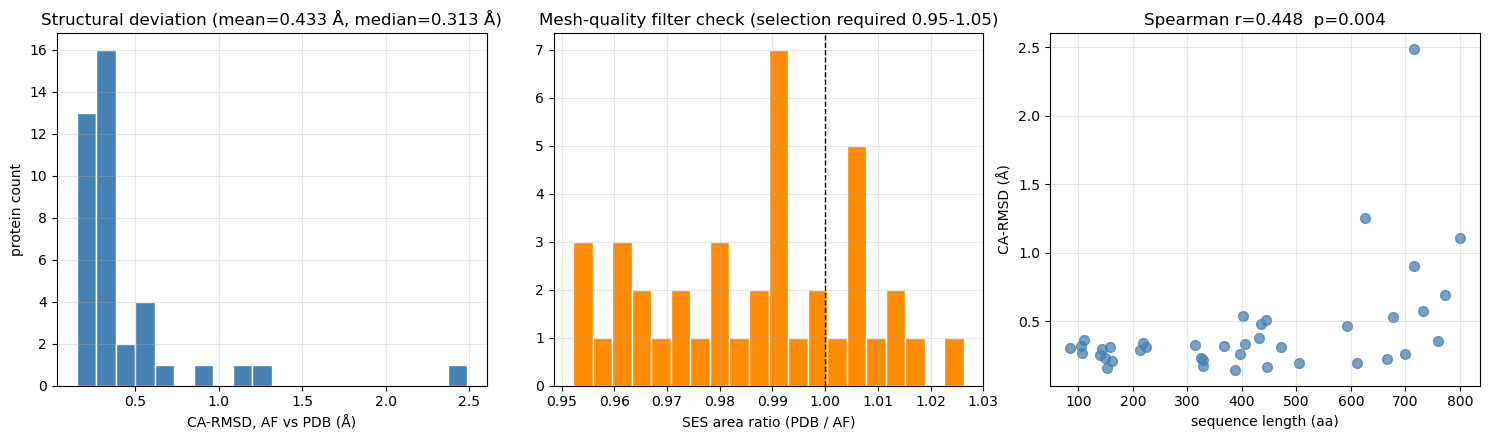

       resolution_A  ca_rmsd_recomputed  alignment_coverage
count     40.000000           40.000000           40.000000
mean       1.737250            0.433184            0.982759
std        0.239315            0.411668            0.013317
min        1.120000            0.147109            0.950479
25%        1.600000            0.231725            0.972456
50%        1.800000            0.313110            0.984394
75%        1.920000            0.471768            0.994162
max        2.000000            2.487828            1.000000


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].hist(df["ca_rmsd_recomputed"], bins=20, color="steelblue", edgecolor="white")
axes[0].set_xlabel("CA-RMSD, AF vs PDB (\u00c5)")
axes[0].set_ylabel("protein count")
axes[0].set_title(f"Structural deviation (mean={df['ca_rmsd_recomputed'].mean():.3f} \u00c5, "
                   f"median={df['ca_rmsd_recomputed'].median():.3f} \u00c5)")
axes[0].grid(alpha=0.3)

area_ratio = df["ses_area_pdb"] / df["ses_area_af"]
axes[1].hist(area_ratio, bins=20, color="darkorange", edgecolor="white")
axes[1].axvline(1.0, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel("SES area ratio (PDB / AF)")
axes[1].set_title("Mesh-quality filter check (selection required 0.95-1.05)")
axes[1].grid(alpha=0.3)

axes[2].scatter(df["sequence_length"], df["ca_rmsd_recomputed"], s=50, alpha=0.75, color="steelblue")
r = spearmanr(df["sequence_length"], df["ca_rmsd_recomputed"])
axes[2].set_xlabel("sequence length (aa)")
axes[2].set_ylabel("CA-RMSD (\u00c5)")
axes[2].set_title(f"Spearman r={r.correlation:.3f}  p={r.pvalue:.3f}")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(df[["resolution_A", "ca_rmsd_recomputed", "alignment_coverage"]].describe())

---
## 3. ESP-Field Comparison

Does more geometric deviation predict more ESP-field deviation? (This is
also a validity check on the whole comparison methodology -- if it didn't
hold, something would be wrong with the RBF cross-structure interpolation.)

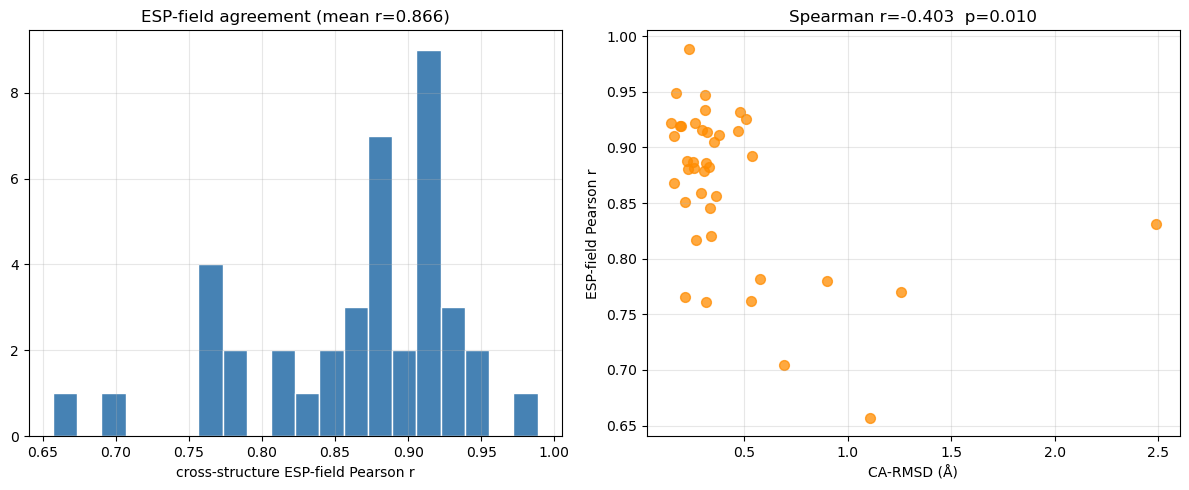

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df["esp_field_r"], bins=20, color="steelblue", edgecolor="white")
axes[0].set_xlabel("cross-structure ESP-field Pearson r")
axes[0].set_title(f"ESP-field agreement (mean r={df['esp_field_r'].mean():.3f})")
axes[0].grid(alpha=0.3)

axes[1].scatter(df["ca_rmsd_recomputed"], df["esp_field_r"], s=50, alpha=0.75, color="darkorange")
r = spearmanr(df["ca_rmsd_recomputed"], df["esp_field_r"])
axes[1].set_xlabel("CA-RMSD (\u00c5)")
axes[1].set_ylabel("ESP-field Pearson r")
axes[1].set_title(f"Spearman r={r.correlation:.3f}  p={r.pvalue:.3f}")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
# Illustrative examples: best- and worst-agreement pairs
best = df.loc[df["esp_field_r"].idxmax()]
worst = df.loc[df["esp_field_r"].idxmin()]
for label, row in [("Best ESP-field agreement", best), ("Worst ESP-field agreement", worst)]:
    print(f"{label}: {row['uniprot_id']} ({row['af_protein_id']} vs {row['pdb_protein_id']})  "
          f"CA-RMSD={row['ca_rmsd_recomputed']:.3f}\u00c5  ESP-field r={row['esp_field_r']:.4f}  "
          f"seq_len={row['sequence_length']}")

Best ESP-field agreement: D2Z027 (AF-D2Z027-F1 vs PDB-D2Z027-3X44-B)  CA-RMSD=0.232Å  ESP-field r=0.9885  seq_len=324
Worst ESP-field agreement: Q76IQ9 (AF-Q76IQ9-F1 vs PDB-Q76IQ9-1V7V-A)  CA-RMSD=1.110Å  ESP-field r=0.6570  seq_len=801


---
## 4. Model Error: AF-Structure vs. PDB-Structure

The central question: paired comparison (same 40 proteins) of model error
on the AlphaFold structure vs. the real experimental structure. A **Wilcoxon
signed-rank test** on the paired differences gives real statistical power
at n=40 (unlike the n=10 seed-conformation pilot).

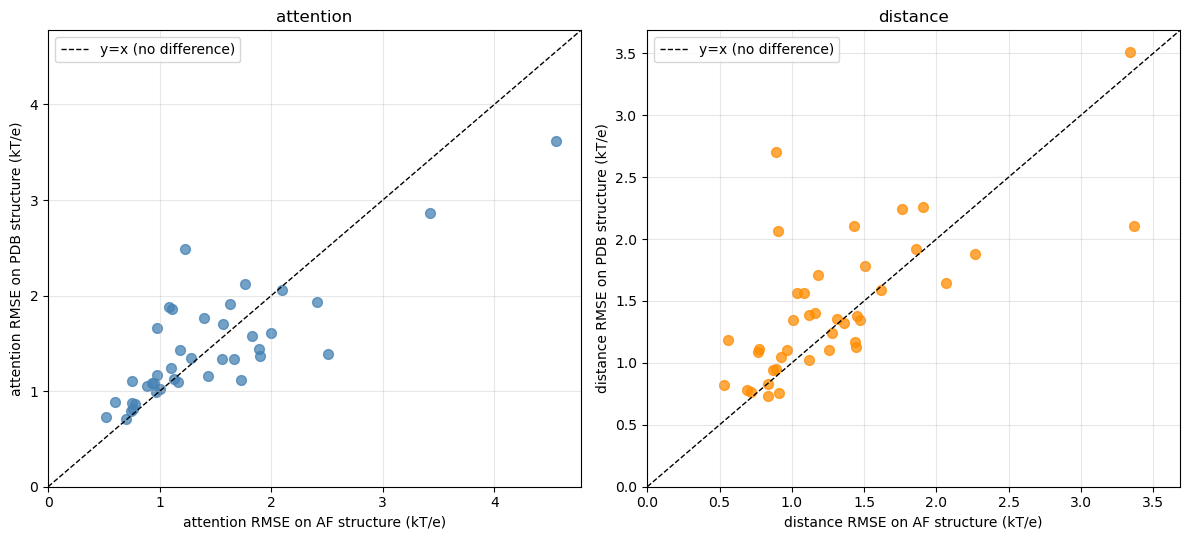

Paired summary (n=40 proteins):

attention:
  mean RMSE  AF=1.4229  PDB=1.4405  (delta=+0.0176, worse on PDB)
  median RMSE  AF=1.1742  PDB=1.3359
  Wilcoxon signed-rank: statistic=367.0  p=0.5717
  25/40 proteins worse on PDB structure

distance:
  mean RMSE  AF=1.2977  PDB=1.4493  (delta=+0.1517, worse on PDB)
  median RMSE  AF=1.1401  PDB=1.3465
  Wilcoxon signed-rank: statistic=242.0  p=0.0232
  25/40 proteins worse on PDB structure


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, model in zip(axes, ["attention", "distance"]):
    x, y = df[f"{model}_rmse_af"], df[f"{model}_rmse_pdb"]
    ax.scatter(x, y, s=50, alpha=0.75, color=MODEL_COLORS[model])
    lims = [0, max(x.max(), y.max()) * 1.05]
    ax.plot(lims, lims, "k--", linewidth=1, label="y=x (no difference)")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel(f"{model} RMSE on AF structure (kT/e)")
    ax.set_ylabel(f"{model} RMSE on PDB structure (kT/e)")
    ax.set_title(model)
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Paired summary (n=40 proteins):")
for model in ["attention", "distance"]:
    af_rmse, pdb_rmse = df[f"{model}_rmse_af"], df[f"{model}_rmse_pdb"]
    delta = df[f"{model}_rmse_delta"]
    stat, p = wilcoxon(af_rmse, pdb_rmse)
    n_worse_on_pdb = (delta > 0).sum()
    print(f"\n{model}:")
    print(f"  mean RMSE  AF={af_rmse.mean():.4f}  PDB={pdb_rmse.mean():.4f}  "
          f"(delta={delta.mean():+.4f}, {'worse' if delta.mean()>0 else 'better'} on PDB)")
    print(f"  median RMSE  AF={af_rmse.median():.4f}  PDB={pdb_rmse.median():.4f}")
    print(f"  Wilcoxon signed-rank: statistic={stat:.1f}  p={p:.4f}")
    print(f"  {n_worse_on_pdb}/40 proteins worse on PDB structure")

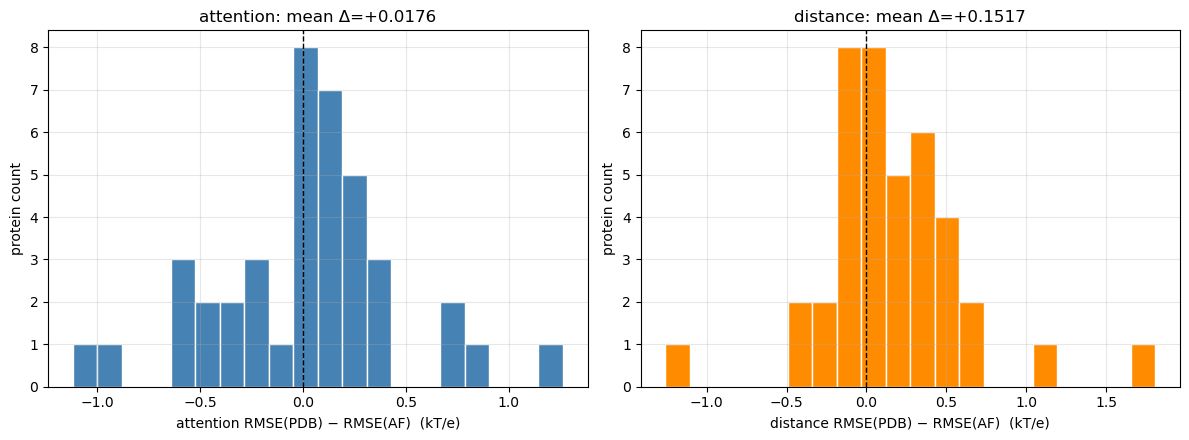

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, model in zip(axes, ["attention", "distance"]):
    ax.hist(df[f"{model}_rmse_delta"], bins=20, color=MODEL_COLORS[model], edgecolor="white")
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_xlabel(f"{model} RMSE(PDB) \u2212 RMSE(AF)  (kT/e)")
    ax.set_ylabel("protein count")
    ax.set_title(f"{model}: mean \u0394={df[f'{model}_rmse_delta'].mean():+.4f}")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. Does Structural/ESP-Field Disagreement Explain the AF-vs-PDB Error Gap?

If a protein's AF-vs-PDB RMSE gap correlates with how geometrically
different the two structures are, the model is sensitive to the *specific*
AF-vs-real deviations (a geometry story). If the gap exists but doesn't
correlate with structural deviation, that points to a more generic
AF-vs-PDB domain shift (mesh/surface artifacts, hydrogen placement
conventions, etc.) rather than deviation-magnitude-driven error.

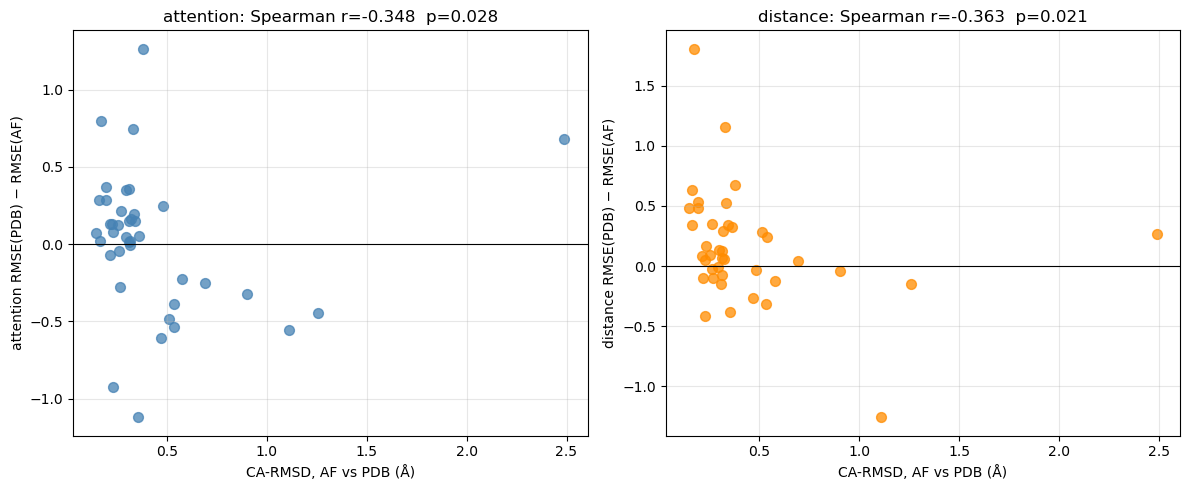

attention: RMSE-delta vs CA-RMSD  r=-0.348 p=0.028   vs ESP-field r  r=0.206 p=0.201
distance: RMSE-delta vs CA-RMSD  r=-0.363 p=0.021   vs ESP-field r  r=0.295 p=0.064


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, model in zip(axes, ["attention", "distance"]):
    delta = df[f"{model}_rmse_delta"]
    ax.scatter(df["ca_rmsd_recomputed"], delta, s=50, alpha=0.75, color=MODEL_COLORS[model])
    ax.axhline(0, color="black", linewidth=0.8)
    r = spearmanr(df["ca_rmsd_recomputed"], delta)
    ax.set_xlabel("CA-RMSD, AF vs PDB (\u00c5)")
    ax.set_ylabel(f"{model} RMSE(PDB) \u2212 RMSE(AF)")
    ax.set_title(f"{model}: Spearman r={r.correlation:.3f}  p={r.pvalue:.3f}")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for model in ["attention", "distance"]:
    delta = df[f"{model}_rmse_delta"]
    r_ca = spearmanr(df["ca_rmsd_recomputed"], delta)
    r_field = spearmanr(df["esp_field_r"], delta)
    print(f"{model}: RMSE-delta vs CA-RMSD  r={r_ca.correlation:.3f} p={r_ca.pvalue:.3f}   "
          f"vs ESP-field r  r={r_field.correlation:.3f} p={r_field.pvalue:.3f}")

---
## 6. Notes & Findings

**Headline result: the two architectures generalize to real structures differently — attention generalizes cleanly, distance shows a real (if modest) degradation.**

| | mean RMSE, AF | mean RMSE, PDB | mean Δ | Wilcoxon p | worse on PDB |
|---|---|---|---|---|---|
| attention | 1.423 | 1.441 | +0.018 (1.2%) | 0.572 (n.s.) | 25/40 |
| distance | 1.298 | 1.449 | +0.152 (11.7%) | **0.023** | 25/40 |

Both models show the same *count* of proteins doing worse on PDB (25/40 = 62.5%), but the *magnitude* differs sharply: attention's mean degradation is negligible and not statistically distinguishable from noise, while distance's is nearly an order of magnitude larger in absolute terms and clears significance at α=0.05. **This directly answers the overfitting-vs-generalization question, and the answer is architecture-dependent**: there's no strong evidence attention overfits to AlphaFold-specific structural quirks, but there is real (modest) evidence distance does. This is a new asymmetry between the two architectures that none of the earlier notebooks surfaced — everywhere else this session (error clustering, embedding analysis, charge probing, uncertainty analysis) attention and distance tracked each other closely; this is the first place they diverge in a way that favors one architecture's generalization over the other's.

**Geometry and ESP-field comparison validate the methodology and are unsurprising on their own**: CA-RMSD is small (mean 0.43 Å, median 0.31 Å) — expected, since the dataset was explicitly built from high-pLDDT AF structures paired with high-resolution PDB structures. ESP-field agreement is correspondingly high (mean r=0.866, mean RMSE=1.91 kT/e) and, reassuringly, correlates with structural deviation in the expected direction — the worst-agreeing pair (Q76IQ9, r=0.657) is also the longest protein in the set (801 aa) and has one of the largest CA-RMSDs (1.11 Å), while the best-agreeing pair (D2Z027, r=0.989) has a small CA-RMSD (0.23 Å). This is exactly what should happen if the cross-structure RBF-interpolation comparison is measuring something real, not an artifact.

**A genuinely counterintuitive result, with a plausible confound identified**: `RMSE(PDB) − RMSE(AF)` correlates *negatively* with CA-RMSD for both models (attention r=−0.348 p=0.028; distance r=−0.363 p=0.021) — i.e., pairs with *more* structural deviation show a *smaller* PDB-vs-AF error gap, the opposite of the naive "more geometric deviation → more extra error" expectation. Before reading this as a real effect, note: sequence length correlates positively with CA-RMSD (r=0.448, p=0.004 — longer proteins have more room for loop/terminus disorder) and negatively with the RMSE gap (r=−0.365 attention, r=−0.295 distance) independently. That's consistent with protein size mediating both relationships (matching this whole session's dominant size-driven-error theme from `error_clustering_analysis.ipynb`) rather than structural deviation *directly* buying the model anything on PDB structures. Disentangling this properly would need a partial-correlation or regression controlling for length — flagged here as a real follow-up, not resolved in this pilot-scale (n=40) notebook.

**Practical takeaway for the thesis**: the ESP-prediction task itself appears to transfer reasonably well from AlphaFold-structure training to real experimental structures — there's no dramatic failure mode here (RMSE on PDB stays within ~1–12% of RMSE on AF for both architectures, nothing like the 2–4x blowups seen for genuinely hard proteins in `error_clustering_analysis.ipynb`). But the direction of the answer is architecture-specific: if forced to pick one champion for deployment against real structures, this pilot favors **attention** on generalization grounds, on top of its already-established edge in charge-probing accuracy (`partial_charge_probe.ipynb`) — though distance's degradation here (a ~12% RMSE increase) is still modest in absolute terms, not a disqualifying failure.
